In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/ML CSE 3202/ford.csv')

In [4]:
print(df.head())
print(df.info())
print(df.describe())

     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  fl

In [5]:
print(df.isnull().sum())

# Remove missing values

df.dropna(inplace=True)

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


In [6]:
median_price = df['price'].median()

# Expensive = 1, Affordable = 0

df['price_category'] = (df['price'] > median_price).astype(int)

In [7]:
categorical_cols = ['model', 'transmission', 'fuelType']

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [8]:
X = df.drop(['price', 'price_category'], axis=1)
y = df['price_category']

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print('Training Shape:', X_train.shape)
print('Validation Shape:', X_val.shape)
print('Testing Shape:', X_test.shape)

Training Shape: (12576, 8)
Validation Shape: (2695, 8)
Testing Shape: (2695, 8)


In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print('Accuracy :', accuracy)
print('Precision:', precision)
print('Recall   :', recall)
print('F1 Score :', f1)
print('AUC Score:', auc)

Accuracy : 0.8597402597402597
Precision: 0.8622754491017964
Recall   : 0.8558692421991084
F1 Score : 0.8590604026845637
AUC Score: 0.9356504240111821


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1349
           1       0.86      0.86      0.86      1346

    accuracy                           0.86      2695
   macro avg       0.86      0.86      0.86      2695
weighted avg       0.86      0.86      0.86      2695



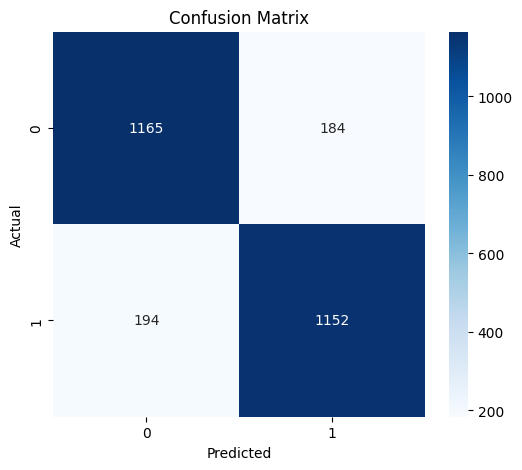

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

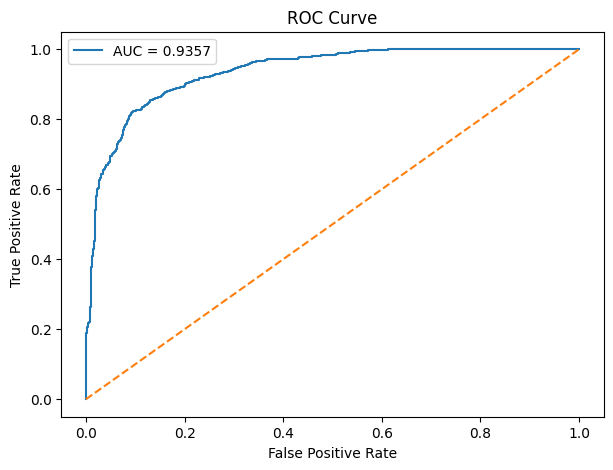

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [17]:
sample_results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Probability Score': y_prob[:10]
})

print(sample_results)

   Actual  Predicted  Probability Score
0       0          1           0.580256
1       1          1           0.991050
2       1          1           0.968478
3       1          1           0.829074
4       1          0           0.069136
5       0          0           0.059833
6       1          1           0.935643
7       0          0           0.107485
8       0          1           0.625805
9       1          0           0.225999
